<a href="https://colab.research.google.com/github/anirban2003-web/Hubble-tension-literature-review/blob/main/notebooks/01_representative_h0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [ ]:
df = pd.read_csv("h0_representative_measurements.csv")

print(df)




           measurement     H0  error   type                       source  \
0          Planck 2018  67.40   0.50  Early  Planck Collaboration (2020)   
1              ACT DR4  67.90   1.50  Early          Aiola et al. (2020)   
2  BAO+BBN (SDSS DR16)  67.35   0.97  Early           Alam et al. (2021)   
3      TDCOSMO lensing  74.20   1.60   Late         Millon et al. (2020)   
4            CCHP TRGB  69.80   1.90   Late       Freedman et al. (2021)   
5           SH0ES 2022  73.04   1.04   Late          Riess et al. (2022)   
6                  SBF  73.30   2.50   Late      Blakeslee et al. (2021)   

                                             doi  
0    https://doi.org/10.1051/0004-6361/201833910  
1  https://doi.org/10.1088/1475-7516/2020/12/047  
2    https://doi.org/10.1103/PhysRevD.103.083533  
3    https://doi.org/10.1051/0004-6361/202038861  
4       https://doi.org/10.3847/1538-4357/ac0e95  
5       https://doi.org/10.3847/2041-8213/ac5c5b  
6       https://doi.org/10.3847/15

In [ ]:
order = [
    "SBF",
    "SHOES 2022",
    "CCHP TRGB",
    "TDCOSMO lensing",
    "BAO+BBN (SDSS DR16)",
    "ACT DR4",
    "Planck 2018"
]

df["measurement"] = pd.Categorical(
    df["measurement"],
    categories=order,
    ordered=True
)

df = df.sort_values("measurement").reset_index(drop=True)

df = df.iloc[::-1].reset_index(drop=True)

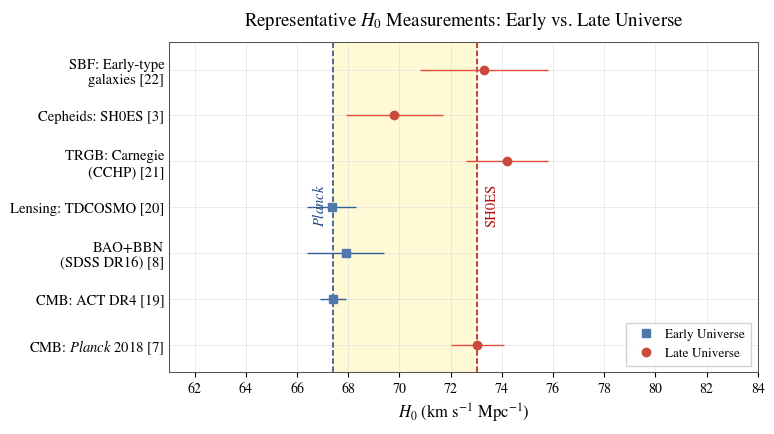

In [ ]:
H0 = df["H0"].to_numpy()
error = df["error"].to_numpy()
types = df["type"].to_numpy()
measurements = df["measurement"].astype(str).to_numpy()

y = np.arange(len(df))

VISUAL_REPRODUCTION = False

if VISUAL_REPRODUCTION:
    idx = np.where(measurements == "TDCOSMO lensing")[0][0]
    H0[idx] = 74.5
    error[idx] = 5.5

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix"
})

fig, ax = plt.subplots(
    figsize=(8.92, 4.75),
    dpi=100
)
ax.axvspan(
    67.4,
    73.04,
    color="#fff7b3",
    alpha=0.55,
    zorder=0
)

ax.axvline(
    67.4,
    color="#17457f",
    linestyle="--",
    linewidth=1.1,
    zorder=1
)

ax.axvline(
    73.04,
    color="#b20f0f",
    linestyle="--",
    linewidth=1.1,
    zorder=1
)


for i in range(len(df)):

    if types[i] == "Early":

        ax.errorbar(
            H0[i],
            y[i],
            xerr=error[i],
            fmt="s",
            markersize=6,
            markerfacecolor="#4f78ad",
            markeredgecolor="#4f78ad",
            ecolor="#315f9a",
            elinewidth=1.0,
            capsize=0,
            linestyle="none",
            zorder=3
        )

    else:

        ax.errorbar(
            H0[i],
            y[i],
            xerr=error[i],
            fmt="o",
            markersize=6,
            markerfacecolor="#c94a3a",
            markeredgecolor="#c94a3a",
            ecolor="#e34b3b",
            elinewidth=1.0,
            capsize=0,
            linestyle="none",
            zorder=3
        )


        display_labels = [
    r"SBF: Early-type" + "\n" + r"galaxies [22]",
    r"Cepheids: SH0ES [3]",
    r"TRGB: Carnegie" + "\n" + r"(CCHP) [21]",
    r"Lensing: TDCOSMO [20]",
    r"BAO+BBN" + "\n" + r"(SDSS DR16) [8]",
    r"CMB: ACT DR4 [19]",
    r"CMB: $\it{Planck}$ 2018 [7]"
]

ax.set_yticks(y)
ax.set_yticklabels(
    display_labels[::-1],
    fontsize=10.5
)

ax.text(
    67.4 - 0.55,
    3.05,
    r"$\it{Planck}$",
    rotation=90,
    ha="center",
    va="center",
    color="#17457f",
    fontsize=10.5
)

ax.text(
    73.04 + 0.55,
    3.05,
    "SH0ES",
    rotation=90,
    ha="center",
    va="center",
    color="#b20f0f",
    fontsize=10.5
)

ax.set_xlim(61, 84)
ax.set_ylim(-0.6, 6.6)

ax.set_xticks(np.arange(62, 85, 2))

ax.tick_params(
    axis="x",
    labelsize=10
)

ax.tick_params(
    axis="y",
    length=0
)

ax.grid(
    True,
    which="major",
    axis="both",
    color="#d9d9d9",
    linewidth=0.55,
    alpha=0.65
)

ax.set_axisbelow(True)

ax.set_xlabel(
    r"$H_0$ (km s$^{-1}$ Mpc$^{-1}$)",
    fontsize=12
)

ax.set_title(
    r"Representative $H_0$ Measurements: Early vs. Late Universe",
    fontsize=13.5,
    pad=12
)

legend_elements = [

    Line2D(
        [0],
        [0],
        marker="s",
        color="none",
        markerfacecolor="#4f78ad",
        markeredgecolor="#4f78ad",
        markersize=6,
        label="Early Universe"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="#c94a3a",
        markeredgecolor="#c94a3a",
        markersize=6,
        label="Late Universe"
    )
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=9.5,
    frameon=True,
    fancybox=False,
    framealpha=0.88,
    borderpad=0.45,
    handletextpad=0.5
)

for spine in ax.spines.values():
    spine.set_linewidth(0.75)
    spine.set_color("#555555")


plt.subplots_adjust(
    left=0.305,
    right=0.965,
    top=0.875,
    bottom=0.18
)

plt.savefig(
    "figure1_representative_H0_measurements.png",
    dpi=300,
    facecolor="white"
)

plt.show()